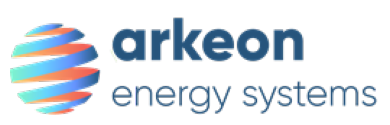

In [1]:
import pandas as pd
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

startdate = pd.Timestamp("2026-02-16")
enddate   = pd.Timestamp("2026-02-17")
nowdate = pd.Timestamp.now().normalize()

startdate_str = startdate.strftime("%Y-%m-%d")
enddate_str   = enddate.strftime("%Y-%m-%d")
nowdate_str   = nowdate.strftime("%Y-%m-%d")

generate_pdf = 0
generate_html = 1

# Display logo only
fig, ax = plt.subplots(figsize=(4, 2))

try:
    logo_path = Path('../images/logo.png')
    if logo_path.exists():
        img = mpimg.imread(logo_path)
        ax.imshow(img)
    ax.axis('off')
except:
    ax.text(0.5, 0.5, 'Logo', ha='center', va='center', fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

# Analyse de pilotage journalier

**Site :** Pervenches-Bruyères | **Système :** PAC ARKEON

In [2]:
display(Markdown(f"**Date** : {startdate_str} → {enddate_str}\n\n---"))

**Date** : 2026-02-16 → 2026-02-17

---

## 1. Paramètres généraux, acquisition, et traitement

### 1.1. Paramètres généraux

In [ ]:
# CELL 1: Import Libraries and Configure Project Paths
# This cell imports all necessary libraries (pandas, numpy, matplotlib) and custom modules
# for data acquisition, API access, and pricing calculations. It also sets up the project
# root path to enable proper module imports from the src/ directory.

import os
import json
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

# Add project root to sys.path for module imports
NOTEBOOKS_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOKS_DIR.parent
sys.path.append(str(PROJECT_ROOT))

from src.acquisition.acquisition import InfluxConfig, run_acquisition
from src.acquisition.endis_api import fetch_consumption_range as get_el_consumption_from_enedis
from src.transform_and_metrics.prix_MWh_elec_TTC import prix_MWh_elec_TTC
from src.transform_and_metrics.prix_MWh_elec_TTC_ENEFFIC import prix_MWh_elec_TTC_ENEFFIC


DATA_DIR = PROJECT_ROOT / "data"
ENEDIS_DIR = DATA_DIR / "ENEDIS"

csv_path = DATA_DIR / f"data_AllData_combined_{startdate_str}_to_{enddate_str}.csv"
json_path = ENEDIS_DIR / f"metering_data_{startdate_str}_to_{enddate_str}.json"

print(f"Configuration du projet...")
# print(f"  Racine du projet : {PROJECT_ROOT}")
# print(f"  Répertoire de données : {DATA_DIR}")
print(f"  Racine et répertoire de données configurés.")
print(f"  Fichiers de données configurés.")
# print(f"    - CSV InfluxDB : {csv_path.name}")
# print(f"    - JSON ENEDIS : {json_path.name}")

0.29
128.71
3.9685318
Configuration du projet...
  Racine et répertoire de données configurés.
  Fichiers de données configurés.


### 1.2. Acquisition des données système (InfluxDB)

In [4]:
# CELL 2: Data Acquisition from InfluxDB and ENEDIS API
# This cell handles data import from two sources:
# 1. System data (temperature, energy, heat pump status) from InfluxDB database
# 2. Electricity consumption data from ENEDIS API (French grid operator)
# Both datasets are cached as CSV/JSON files to avoid redundant API calls.
# ENEDIS data is resampled from 5-minute intervals to hourly aggregations.

# IMPORT DATA FROM DATABASE AND ENEDIS API
startdate_influx = startdate - np.timedelta64(1, 'h')
enddate_influx   = enddate - np.timedelta64(1, 'h')

startdate_influx_str = startdate_influx.strftime("%Y-%m-%d %H:%M")
enddate_influx_str   = enddate_influx.strftime("%Y-%m-%d %H:%M")

print(f"Acquisition de données pour la période : {startdate_str} au {enddate_str}")
# print(f"Fichier de données InfluxDB : {csv_path.name}")
# print(f"Fichier de données ENEDIS : {json_path.name}")
print()

# Import system data from database

if os.path.exists(csv_path):
    #print(f"Le fichier données existe déjà. Chargement des données existantes...")
    df = pd.read_csv(csv_path)
else:
    #print(f"Fichier données non trouvé. Lancement de l'acquisition...")
    
    intervals = [{"start_date": startdate_str, "end_date": enddate_str, "description": "Semaine"}]

    result = run_acquisition(
        date_intervals=intervals,
        fields=[
                "TT_ext", "RH_ext", "price",
                "dis_mode", "Temp_SC_Charge",
                "DIS_STS_A_TT1", "DIS_STS_R_TT1"],
        use_specific_fields=True,
        output_dir="../data",
        query_mode="daily",
        data_step="1m",
        influx=InfluxConfig(),
    )
    
    # Load the newly created file
    df = pd.read_csv(csv_path)
    #print("Acquisition de données terminée et chargée.")


# Import electric consulmption data from ENEDIS api or file if already exists

if os.path.exists(json_path):
    #print(f"Le fichier données ENEDIS existe déjà. Chargement des données existantes...")
    a = 1
else:
    #print(f"Fichier données ENEDIS non trouvé. Récupération des données depuis ENEDIS...")
    result = get_el_consumption_from_enedis(startdate_str, enddate_str, output_dir="../data/ENEDIS")
    #print(result["file"])
# Load the JSON file
with open(json_path, 'r') as f:
    data = json.load(f)

# Extract the interval readings
interval_readings = data['meter_reading']['interval_reading']

# Or if you want to expand the arrays:
rows = []
for reading in interval_readings:
    rows.append({
        'date': reading['date'][0],
        'power_W': int(reading['value'][0]),
        'reactive_VAr': int(reading['value'][1])
    })
df_enedis = pd.DataFrame(rows)

df_enedis['el_energy_kWh'] = df_enedis['power_W'] * (5*60/3600) / 1000  # Assuming 5-minute intervals

df_enedis['date'] = pd.to_datetime(df_enedis['date'])

df_enedis.set_index('date', inplace=True)

df_resampled_enedis = df_enedis.resample('h').agg({
    'power_W': 'max',
    'reactive_VAr': 'max',
    'el_energy_kWh': 'sum'
}).round(2)


Acquisition de données pour la période : 2026-02-16 au 2026-02-17



### 1.3. Traitements & agrégats horaires et journaliers

In [5]:
# CELL 3: Data Processing, Metrics Calculation, and Aggregation
# This cell performs the core data processing pipeline:
# 1. Fill missing 1-minute data gaps with NaN values (for power outages)
# 2. Calculate performance metrics: COP (Coefficient of Performance), thermal energy, SPF (Seasonal Performance Factor)
# 3. Aggregate data from 1-minute to hourly and daily intervals
# 4. Merge electricity consumption data and calculate costs using French tariff structure
# 5. Generate daily statistics including temperature ranges, energy consumption, and system performance

timeStep_hours  = 60/3600

# Convert _time to datetime and remove timezone awareness
df['_time'] = pd.to_datetime(df['_time']).dt.tz_localize(None)

# Filter data to keep only dates strictly before enddate
df = df[df['_time'] < enddate]

# Set _time as index temporarily
df = df.set_index('_time')

# Create a complete datetime index with 1-minute intervals
full_time_index = pd.date_range(start=df.index.min(), end=df.index.max(), freq='1min')

# Count missing data points
original_count = len(df)
expected_count = len(full_time_index)
missing_count = expected_count - original_count

# Reindex to fill gaps with NaN
df = df.reindex(full_time_index)

# Reset index to make _time a column again
df = df.reset_index().rename(columns={'index': '_time'})

# Print the number of lines added
print(f"Points de données d'origine : {original_count}")
print(f"Points de données attendus : {expected_count}")
print(f"Points de données manquants remplis : {missing_count}")

# Print sample of added lines (first few NaN rows)
if missing_count > 0:
   nan_rows = df[df.iloc[:, 1:].isnull().all(axis=1)]
   if len(nan_rows) > 0:
      print("\nPoints de données manquants ajoutés à ces horodatages :")
      unique_dates = {}
      for i, (idx, row) in enumerate(nan_rows.iterrows()):
         # Format datetime to Y-m-d h:00:00
         formatted_time = row['_time'].strftime('%Y-%m-%d %H:00:00')
         if formatted_time in unique_dates:
            unique_dates[formatted_time] += 1
         else:
            unique_dates[formatted_time] = 1
      
      # Print unique dates sorted with occurrence counts
      for date in sorted(unique_dates.keys()):
         print(f"  {date} ({unique_dates[date]} occurrences)")

#Add metrics columns
df['recharge'] = (df['dis_mode'] == 3)
df['decharge'] = (df['dis_mode'] == 2)
df['direct'] = (df['dis_mode'] == 1)
df['T_stock'] = (df['recharge'] * df['DIS_STS_R_TT1'] + df['decharge'] * df['DIS_STS_A_TT1'])
df['price'] = df['price'].ffill()  # Forward fill

# Fill T_stock based on dis_mode
df['T_stock'] = df['T_stock'].replace(0, np.nan)
df['T_stock'] = df['T_stock'].ffill().fillna(df[['DIS_STS_R_TT1', 'DIS_STS_A_TT1']].min(axis=1))

df_resampled = df.set_index('_time')
# Explicitly infer object types and convert to appropriate dtypes before interpolation
df_resampled = df_resampled.infer_objects(copy=False)
# Only interpolate numeric columns to avoid FutureWarning with object dtype
numeric_cols = df_resampled.select_dtypes(include=[np.number]).columns
df_resampled[numeric_cols] = df_resampled[numeric_cols].interpolate(method='linear').round(2)

# Resample df_resampled to hourly aggregations
hourly_stats = df_resampled[["TT_ext", "RH_ext", "price",
                              "dis_mode", "Temp_SC_Charge",
                              "DIS_STS_A_TT1", "DIS_STS_R_TT1",
                              'recharge', 'decharge', 'T_stock'
                            ]].resample('h').agg({
    'TT_ext': 'mean',
    'RH_ext': 'mean',
    'price': 'mean' ,
    'recharge': ['first', 'mean'],
    'decharge': ['first', 'mean'],
    'Temp_SC_Charge':['first'],
    'T_stock': ['first', 'last'],
}).round(2)

# Flatten MultiIndex columns
hourly_stats.columns = ['_'.join(col).strip('_') for col in hourly_stats.columns.values]

# Merge energy_kWh from ENEDIS data
hourly_stats = hourly_stats.merge(df_resampled_enedis[['el_energy_kWh']], left_index=True, right_index=True, how='left')

# Some NaN values are present, for now the solution is to fill them through interpolation. 
# Should be discussed
hourly_stats = hourly_stats.interpolate(method='linear').round(2)



# Apply prix_MWh_elec_TTC function to calculate electricity prices
# Use prix_MWh_elec_TTC_ENEFFIC for dates after 21/12/2026
hourly_stats[['el_price_fixed', 'el_price_variable']] = hourly_stats.apply(
   lambda row: pd.Series(
      prix_MWh_elec_TTC_ENEFFIC(row.name, row['price_mean'])
      if row.name >= pd.Timestamp('2026-12-21')
      else prix_MWh_elec_TTC(row.name, row['price_mean']) 
   ), axis=1
)

#df_resampled_enedis.to_csv("test.csv")
hourly_stats['el_price_variable'] = hourly_stats['el_price_variable']/1000
hourly_stats['el_energy_cost'] = (hourly_stats['el_price_fixed'] + hourly_stats['el_price_variable'] * hourly_stats['el_energy_kWh']).round(2)


Points de données d'origine : 1440
Points de données attendus : 1440
Points de données manquants remplis : 0


In [6]:
# DEBUG: print head of hourly_stats
print('hourly_stats:')
try:
    display(hourly_stats)
except Exception as e:
    print('Error displaying hourly_stats:', e)

hourly_stats:


,TT_ext_mean,RH_ext_mean,price_mean,recharge_first,recharge_mean,decharge_first,decharge_mean,Temp_SC_Charge_first,T_stock_first,T_stock_last,el_energy_kWh,el_price_fixed,el_price_variable,el_energy_cost
_time,,,,,,,,,,,,,,
2026-02-16 00:00:00,9.02,78.65,0.01,False,0.0,False,0.00,5.0,31.7,31.0,14.08,0.35,0.12992,2.18
2026-02-16 01:00:00,9.09,78.56,0.00,False,0.0,False,0.00,5.0,31.0,30.2,14.58,0.35,0.12991,2.24
2026-02-16 02:00:00,8.80,78.72,-0.00,False,0.0,False,0.00,5.0,30.2,29.4,16.33,0.35,0.12991,2.47
2026-02-16 03:00:00,8.15,84.42,-0.01,False,0.0,False,0.00,5.0,29.4,29.0,16.42,0.35,0.12990,2.48
2026-02-16 04:00:00,8.08,83.38,-0.01,False,0.0,False,0.00,5.0,29.0,28.5,16.50,0.35,0.12990,2.49
2026-02-16 05:00:00,8.07,79.99,-0.00,False,0.0,False,0.00,5.0,28.5,28.1,16.50,0.35,0.12991,2.49
2026-02-16 06:00:00,7.47,84.72,14.00,False,0.0,False,0.00,5.0,28.1,27.8,19.75,0.35,0.15198,3.35
2026-02-16 07:00:00,6.95,87.20,20.59,False,0.0,False,0.00,5.0,27.8,27.5,16.67,0.35,0.15673,2.96
2026-02-16 08:00:00,6.04,89.90,22.00,False,0.0,False,0.00,5.0,27.5,27.4,25.33,0.35,0.15774,4.35


In [7]:
# Create a new dataframe for visualization with selected columns and renamed headers
visualization_df = hourly_stats[['TT_ext_mean', 'price_mean', 'el_price_variable', 'recharge_first', 'decharge_first', 'Temp_SC_Charge_first', 'T_stock_first', 'T_stock_last']].copy()

visualization_df.columns = ['T_ext', 'EURMWH_SPOT', 'EURKWH_variable', 'recharge', 'decharge', 'T_consigne_PAC', 'T_stock_init', 'T_stock_final']

display(visualization_df.head())

,T_ext,EURMWH_SPOT,EURKWH_variable,recharge,decharge,T_consigne_PAC,T_stock_init,T_stock_final
_time,,,,,,,,
2026-02-16 00:00:00,9.02,0.01,0.12992,False,False,5.0,31.7,31.0
2026-02-16 01:00:00,9.09,0.00,0.12991,False,False,5.0,31.0,30.2
2026-02-16 02:00:00,8.80,-0.00,0.12991,False,False,5.0,30.2,29.4
2026-02-16 03:00:00,8.15,-0.01,0.12990,False,False,5.0,29.4,29.0
2026-02-16 04:00:00,8.08,-0.01,0.12990,False,False,5.0,29.0,28.5


In [8]:
input_file = DATA_DIR / "input_pilotage" / "ModeTable_11FEB2026.csv"
hourly_stats_pilotage = pd.read_csv(input_file, sep=';')
display(hourly_stats_pilotage.head())

,heures,T_ext,EURMWH_SPOT,EURKWH_variable,recharge,decharge,T_consigne_PAC,T_stock_init,T_stock_final
0,11-Feb-2026 00:00:00,8.21,13.5425,0.144159,0,1,25.000000,45.000000,44.893379
1,11-Feb-2026 01:00:00,7.73,14.7325,0.145587,0,1,25.000000,44.893379,39.225746
2,11-Feb-2026 02:00:00,6.35,4.3200,0.133092,1,0,42.181161,39.225746,42.181161
3,11-Feb-2026 03:00:00,6.64,-0.0075,0.127899,1,0,43.878166,42.181161,43.878166
4,11-Feb-2026 04:00:00,7.28,-0.0100,0.127896,1,0,48.171122,43.878166,48.171122


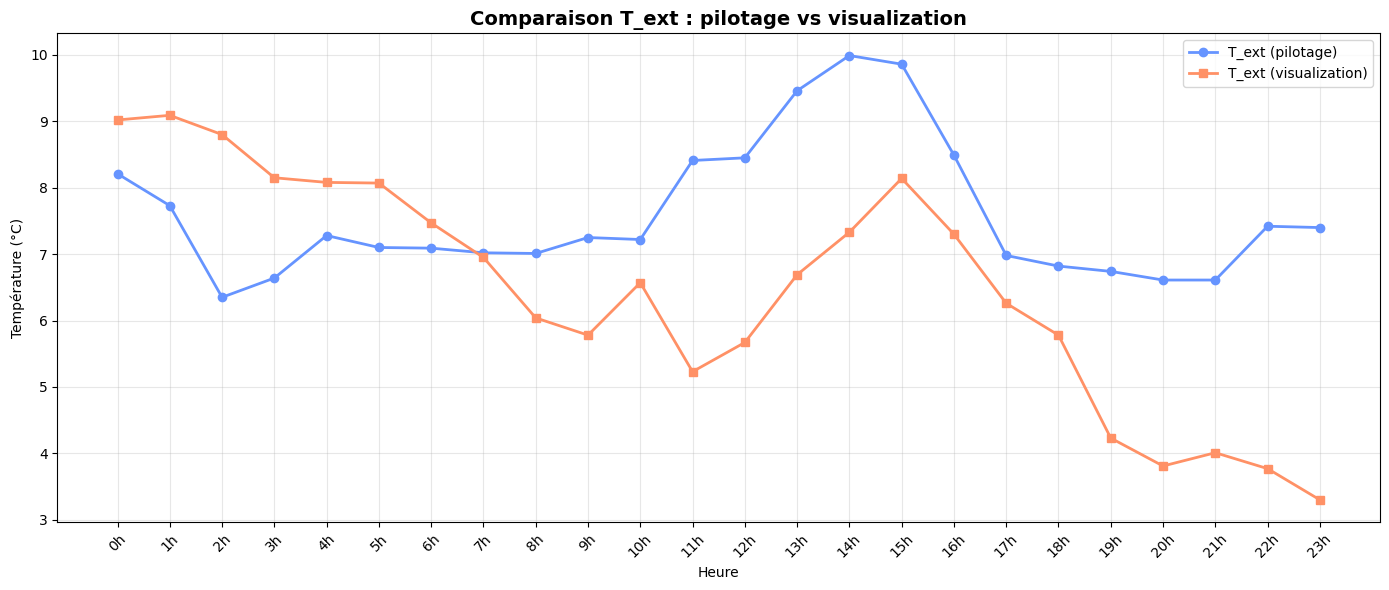

Statistiques T_ext:
Pilotage  - Mean: 7.59°C, Min: 6.35°C, Max: 9.99°C
Visualization - Mean: 6.48°C, Min: 3.30°C, Max: 9.09°C


In [9]:
# Create a comparison plot of T_ext from both dataframes
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(hourly_stats_pilotage))

# Plot T_ext from both dataframes
ax.plot(x, hourly_stats_pilotage['T_ext'], 
    marker='o', linewidth=2, label='T_ext (pilotage)', color='#6694FF')
ax.plot(x, visualization_df['T_ext'], 
    marker='s', linewidth=2, label='T_ext (visualization)', color='#FF9166')

# Customize the plot
ax.set_title('Comparaison T_ext : pilotage vs visualization', fontsize=14, fontweight='bold')
ax.set_xlabel('Heure')
ax.set_ylabel('Température (°C)')
ax.set_xticks(x)
ax.set_xticklabels([f"{i}h" for i in range(24)], rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics comparison
print("Statistiques T_ext:")
print(f"Pilotage  - Mean: {hourly_stats_pilotage['T_ext'].mean():.2f}°C, Min: {hourly_stats_pilotage['T_ext'].min():.2f}°C, Max: {hourly_stats_pilotage['T_ext'].max():.2f}°C")
print(f"Visualization - Mean: {visualization_df['T_ext'].mean():.2f}°C, Min: {visualization_df['T_ext'].min():.2f}°C, Max: {visualization_df['T_ext'].max():.2f}°C")

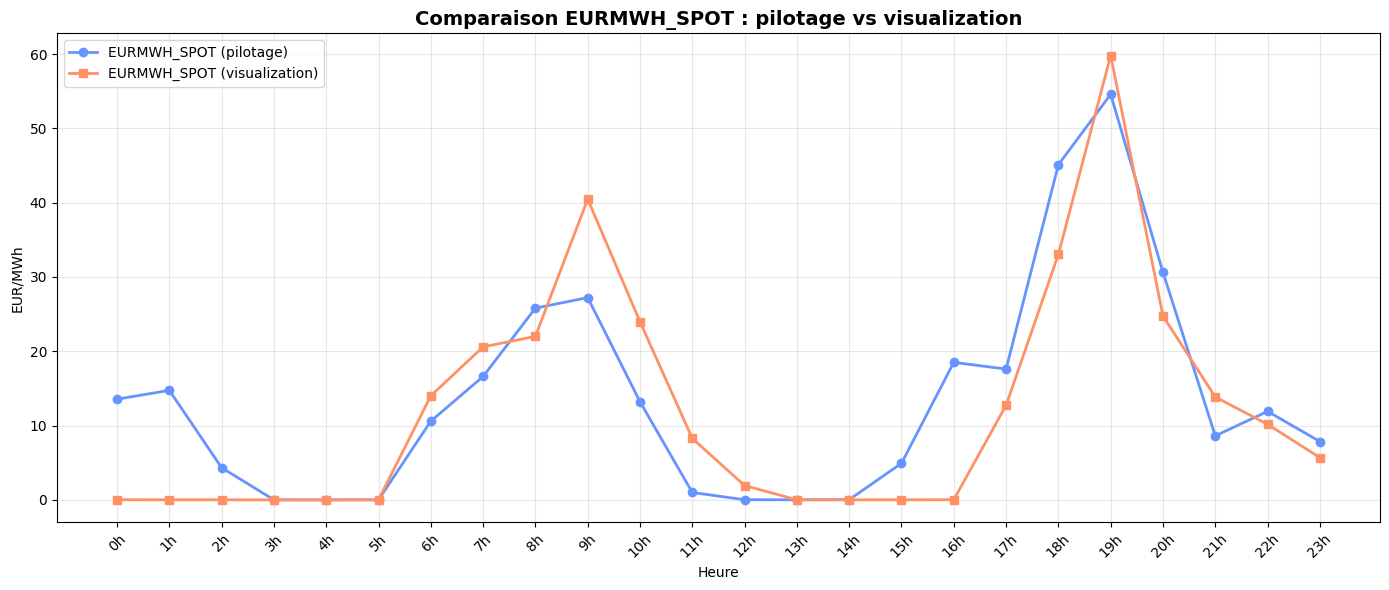

Statistiques EURMWH_SPOT:
Pilotage  - Mean: 13.61 EUR/MWh, Min: -0.01 EUR/MWh, Max: 54.58 EUR/MWh
Visualization - Mean: 12.13 EUR/MWh, Min: -0.01 EUR/MWh, Max: 59.80 EUR/MWh


In [10]:
# Create a comparison plot of EURMWH_SPOT from both dataframes
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(hourly_stats_pilotage))

# Plot EURMWH_SPOT from both dataframes
ax.plot(x, hourly_stats_pilotage['EURMWH_SPOT'], 
    marker='o', linewidth=2, label='EURMWH_SPOT (pilotage)', color='#6694FF')
ax.plot(x, visualization_df['EURMWH_SPOT'], 
    marker='s', linewidth=2, label='EURMWH_SPOT (visualization)', color='#FF9166')

# Customize the plot
ax.set_title('Comparaison EURMWH_SPOT : pilotage vs visualization', fontsize=14, fontweight='bold')
ax.set_xlabel('Heure')
ax.set_ylabel('EUR/MWh')
ax.set_xticks(x)
ax.set_xticklabels([f"{i}h" for i in range(len(x))], rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics comparison
print("Statistiques EURMWH_SPOT:")
print(f"Pilotage  - Mean: {hourly_stats_pilotage['EURMWH_SPOT'].mean():.2f} EUR/MWh, Min: {hourly_stats_pilotage['EURMWH_SPOT'].min():.2f} EUR/MWh, Max: {hourly_stats_pilotage['EURMWH_SPOT'].max():.2f} EUR/MWh")
print(f"Visualization - Mean: {visualization_df['EURMWH_SPOT'].mean():.2f} EUR/MWh, Min: {visualization_df['EURMWH_SPOT'].min():.2f} EUR/MWh, Max: {visualization_df['EURMWH_SPOT'].max():.2f} EUR/MWh")

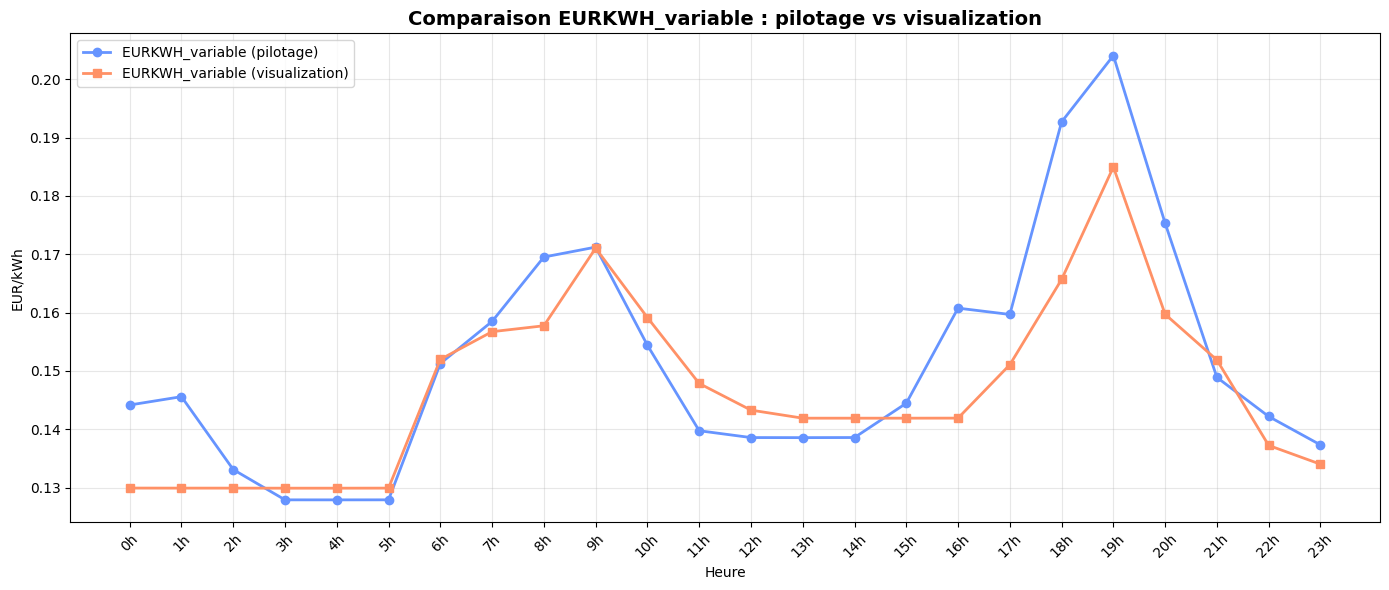

Statistiques EURKWH_VARIABLE:
Pilotage  - Mean: 0.15 EUR/kWh, Min: 0.13 EUR/kWh, Max: 0.20 EUR/kWh
Visualization - Mean: 0.15 EUR/kWh, Min: 0.13 EUR/kWh, Max: 0.18 EUR/kWh


In [11]:
# Create a comparison plot of EURKWH_variable from both dataframes
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(hourly_stats_pilotage))

# Plot EURKWH_variable from both dataframes
ax.plot(x, hourly_stats_pilotage['EURKWH_variable'], 
    marker='o', linewidth=2, label='EURKWH_variable (pilotage)', color='#6694FF')
ax.plot(x, visualization_df['EURKWH_variable'], 
    marker='s', linewidth=2, label='EURKWH_variable (visualization)', color='#FF9166')

# Customize the plot
ax.set_title('Comparaison EURKWH_variable : pilotage vs visualization', fontsize=14, fontweight='bold')
ax.set_xlabel('Heure')
ax.set_ylabel('EUR/kWh')
ax.set_xticks(x)
ax.set_xticklabels([f"{i}h" for i in range(len(x))], rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics comparison
print("Statistiques EURKWH_VARIABLE:")
print(f"Pilotage  - Mean: {hourly_stats_pilotage['EURKWH_variable'].mean():.2f} EUR/kWh, Min: {hourly_stats_pilotage['EURKWH_variable'].min():.2f} EUR/kWh, Max: {hourly_stats_pilotage['EURKWH_variable'].max():.2f} EUR/kWh")
print(f"Visualization - Mean: {visualization_df['EURKWH_variable'].mean():.2f} EUR/kWh, Min: {visualization_df['EURKWH_variable'].min():.2f} EUR/kWh, Max: {visualization_df['EURKWH_variable'].max():.2f} EUR/kWh")

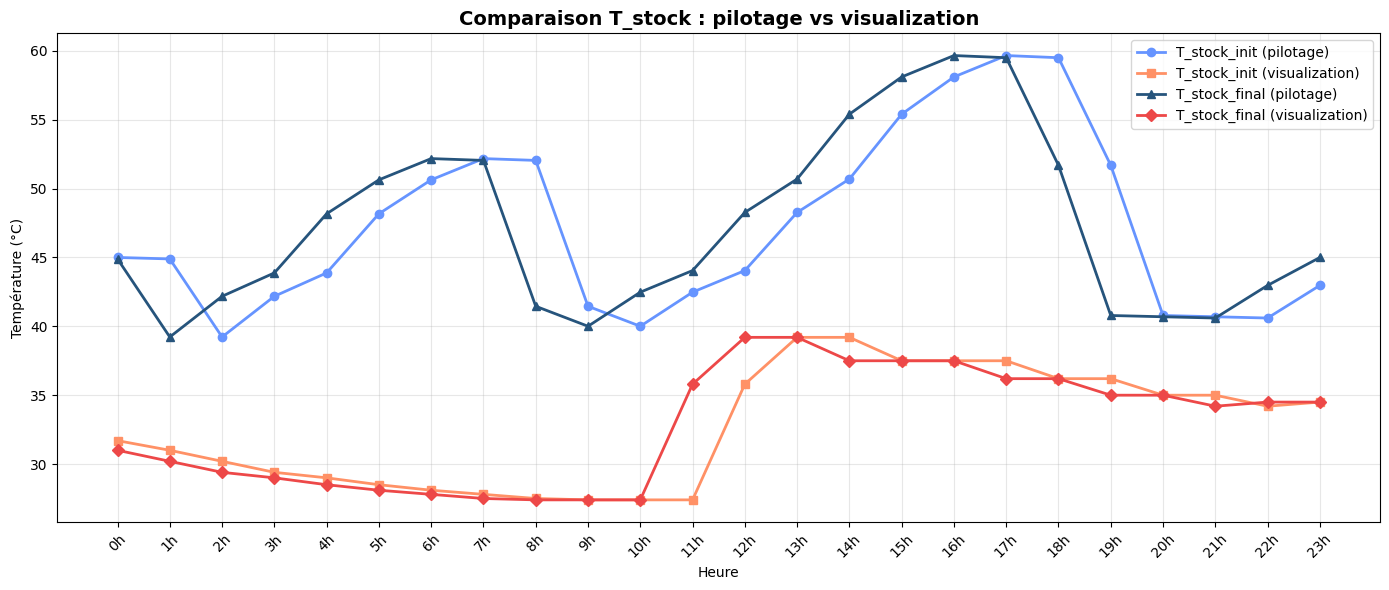

Statistiques T_stock:
Pilotage init  - Mean: 47.27°C, Min: 39.23°C, Max: 59.66°C
Visualization init - Mean: 32.63°C, Min: 27.40°C, Max: 39.20°C

Pilotage final  - Mean: 47.27°C, Min: 39.23°C, Max: 59.66°C
Visualization final - Mean: 32.75°C, Min: 27.40°C, Max: 39.20°C


In [12]:
# Create a comparison plot of T_stock (initial and final) from both dataframes
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(hourly_stats_pilotage))

# Plot T_stock_init from both dataframes
ax.plot(x, hourly_stats_pilotage['T_stock_init'], 
    marker='o', linewidth=2, label='T_stock_init (pilotage)', color='#6694FF')
ax.plot(x, visualization_df['T_stock_init'], 
    marker='s', linewidth=2, label='T_stock_init (visualization)', color='#FF9166')

# Plot T_stock_final from both dataframes
ax.plot(x, hourly_stats_pilotage['T_stock_final'], 
    marker='^', linewidth=2, label='T_stock_final (pilotage)', color='#26547C')
ax.plot(x, visualization_df['T_stock_final'], 
    marker='D', linewidth=2, label='T_stock_final (visualization)', color='#ED4848')

# Customize the plot
ax.set_title('Comparaison T_stock : pilotage vs visualization', fontsize=14, fontweight='bold')
ax.set_xlabel('Heure')
ax.set_ylabel('Température (°C)')
ax.set_xticks(x)
ax.set_xticklabels([f"{i}h" for i in range(len(x))], rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics comparison
print("Statistiques T_stock:")
print(f"Pilotage init  - Mean: {hourly_stats_pilotage['T_stock_init'].mean():.2f}°C, Min: {hourly_stats_pilotage['T_stock_init'].min():.2f}°C, Max: {hourly_stats_pilotage['T_stock_init'].max():.2f}°C")
print(f"Visualization init - Mean: {visualization_df['T_stock_init'].mean():.2f}°C, Min: {visualization_df['T_stock_init'].min():.2f}°C, Max: {visualization_df['T_stock_init'].max():.2f}°C")
print()
print(f"Pilotage final  - Mean: {hourly_stats_pilotage['T_stock_final'].mean():.2f}°C, Min: {hourly_stats_pilotage['T_stock_final'].min():.2f}°C, Max: {hourly_stats_pilotage['T_stock_final'].max():.2f}°C")
print(f"Visualization final - Mean: {visualization_df['T_stock_final'].mean():.2f}°C, Min: {visualization_df['T_stock_final'].min():.2f}°C, Max: {visualization_df['T_stock_final'].max():.2f}°C")

## 2. Visualisation : 

### 2.1. Météo et températures

In [13]:
# CELL 10: Export Report to PDF or HTML
# This cell exports the current notebook as a PDF/HTML report and saves it in the /reports folder
# The filename includes the date range for easy identification

import subprocess
import sys
from pathlib import Path
from IPython.display import Javascript, display

# Save the notebook before export to ensure latest changes are included
print("Sauvegarde du notebook...")
display(Javascript('IPython.notebook.save_checkpoint();'))
import time
time.sleep(2)  # Wait for save to complete
print("Notebook sauvegardé.\n")

# Define the reports directory
REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(exist_ok=True)

# Define the output filenames with date range
pdf_filename = f"rapport_hebdo_PAC_{startdate_str}_to_{enddate_str}.pdf"
html_filename = f"rapport_hebdo_PAC_{startdate_str}_to_{enddate_str}.html"
pdf_path = REPORTS_DIR / pdf_filename
html_path = REPORTS_DIR / html_filename

# Get the current notebook path
notebook_path = NOTEBOOKS_DIR / "Generateur_de_rapport_hebdo.ipynb"

print(f"Export du notebook...")
print(f"Source : {notebook_path}")
print(f"Utilisation de Python : {sys.executable}")

# Export PDF if requested
if generate_pdf:
    print(f"\n--- Export PDF ---")
    try:
        result = subprocess.run(
            [sys.executable, "-m", "nbconvert", "--to", "pdf", 
             "--no-input",
             "--TagRemovePreprocessor.enabled=True",
             "--TagRemovePreprocessor.remove_cell_tags=no-export",
             "--output", str(pdf_path), 
             str(notebook_path)],
            capture_output=True,
            text=True,
            check=True
        )
        
        print(f"✓ PDF exporté avec succès vers : {pdf_path}")
        print(f"  Taille du fichier : {pdf_path.stat().st_size / 1024:.2f} KB")
        
    except subprocess.CalledProcessError as e:
        print(f"✗ Erreur lors de l'export PDF :")
        print(f"  {e.stderr}")
        print(f"\nNote : L'export PDF nécessite nbconvert et LaTeX (par ex., MiKTeX)")
        
    except Exception as e:
        print(f"✗ Erreur : {e}")
        print(f"\nNote : Installez nbconvert avec :")
        print(f"  {sys.executable} -m pip install nbconvert")
else:
    print(f"\n--- Export PDF désactivé (generate_pdf = {generate_pdf}) ---")

# Export HTML if requested
if generate_html:
    print(f"\n--- Export HTML ---")
    try:
        result = subprocess.run(
            [sys.executable, "-m", "nbconvert", "--to", "html", 
             "--no-input",
             "--TagRemovePreprocessor.enabled=True",
             "--TagRemovePreprocessor.remove_cell_tags=no-export",
             "--output", str(html_path), 
             str(notebook_path)],
            capture_output=True,
            text=True,
            check=True
        )
        
        print(f"✓ HTML exporté avec succès vers : {html_path}")
        print(f"  Taille du fichier : {html_path.stat().st_size / 1024:.2f} KB")
        
    except subprocess.CalledProcessError as e:
        print(f"✗ Erreur lors de l'export HTML :")
        print(f"  {e.stderr}")
        
    except Exception as e:
        print(f"✗ Erreur : {e}")
        print(f"\nNote : Installez nbconvert avec :")
        print(f"  {sys.executable} -m pip install nbconvert")
else:
    print(f"\n--- Export HTML désactivé (generate_html = {generate_html}) ---")
    
print(f"\nGénération du rapport terminée à : {nowdate_str}")

Sauvegarde du notebook...


<IPython.core.display.Javascript object>

Notebook sauvegardé.

Export du notebook...
Source : c:\Users\MohamadJoumaa\Arkeon Energy SAS\08_Engineering - Documents\General\08-4 Products design\08-4-8 SMART C&C LAB\04 - Programmation\Dossier Visual Studio de Mo\Analyse_Pilotage_Pervenches_202602\notebooks\Generateur_de_rapport_hebdo.ipynb
Utilisation de Python : c:\Python312\python.exe

--- Export PDF désactivé (generate_pdf = 0) ---

--- Export HTML ---
✗ Erreur lors de l'export HTML :
  [NbConvertApp] WARNING | pattern 'c:\\Users\\MohamadJoumaa\\Arkeon Energy SAS\\08_Engineering - Documents\\General\\08-4 Products design\\08-4-8 SMART C&C LAB\\04 - Programmation\\Dossier Visual Studio de Mo\\Analyse_Pilotage_Pervenches_202602\\notebooks\\Generateur_de_rapport_hebdo.ipynb' matched no files


Génération du rapport terminée à : 2026-02-17
